# **Завдання 1**

## Порівняння архітектур: YOLOv8, RT-DETR, Mask R-CNN

**YOLOv8** — це одноступенева модель, оптимізована для високошвидкісної роботи в реальному часі. Вона базується на CNN з удосконаленою архітектурою PANet та Spatial Pyramid Pooling, що дозволяє ефективно виявляти об'єкти різного масштабу.

**RT-DETR** — це трансформерна модель нового покоління, яка усуває потребу у постпроцесінгу NMS. Завдяки гібридному енкодеру та запитам, що враховують IoU, вона забезпечує швидкий і точний інференс.

**Mask R-CNN** — двоступенева архітектура, що є розширенням Faster R-CNN, з додатковою гілкою для сегментації об'єктів (масок). Вона забезпечує точні результати, але потребує більше часу на інференс.

---

| Модель | Кількість параметрів | Час інференсу (на зображення) | Архітектурні особливості                                   |
|------------------------|----------------------|-------------------------------|------------------------------------------------------------|
| **YOLOv8s** | ~9 млн | ~18.5 мс (54 FPS) | Одноступенева CNN з покращеним PANet та SPP |
| **RT-DETR-R50** | ~50 млн | ~9.2 мс (108 FPS) | Трансформер з гібридним енкодером, IoU-aware запити |
| **Mask R-CNN (R50-FPN)** | ~44 млн | ~43 мс (23 FPS) | Двоступенева R-CNN з гілкою для масок та RoIAlign |

---

### Висновок

- **YOLOv8** — чудово підходить для швидких застосунків, таких як мобільні чи веб-додатки.
- **RT-DETR** — баланс між точністю та швидкістю, ефективна для реального часу.
- **Mask R-CNN** — найкраща для точного виділення контурів об'єктів (наприклад, у медичних або промислових задачах), де час не критичний.


# **Завдання 2**

In [ ]:
!python -m pip install pyyaml==5.1
import sys, os, distutils.core
# Note: This is a faster way to install detectron2 in Colab, but it does not include all functionalities (e.g. compiled operators).
# See https://detectron2.readthedocs.io/tutorials/install.html for full installation instructions
!git clone 'https://github.com/facebookresearch/detectron2'
dist = distutils.core.run_setup("./detectron2/setup.py")
!python -m pip install {' '.join([f"'{x}'" for x in dist.install_requires])}
sys.path.insert(0, os.path.abspath('./detectron2'))

# Properly install detectron2. (Please do not install twice in both ways)
# !python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.2/274.2 kB 12.9 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Cloning into 'detectron2'...
remote: Enumerating objects: 15860, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 15860 (delta 38), reused 15 (delta 13), pack-reused 15783 (from 3)
Receiving objects: 100% (15860/15860), 6.41 MiB | 20.39 MiB/s, done.
Resolving deltas: 100% (11541/11541), done.
Ignoring dataclasses: markers 'python_version < "3.7"' don't match your en

In [ ]:
import torch, detectron2
!nvcc --version
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)
print("detectron2:", detectron2.__version__)

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0
torch:  2.6 ; cuda:  cu124
detectron2: 0.6


In [ ]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random
from google.colab.patches import cv2_imshow

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

In [ ]:
cfg = get_cfg()
# add project-specific config (e.g., TensorMask) here if you're not running a model in detectron2's core library
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # set threshold for this model
# Find a model from detectron2's model zoo. You can use the https://dl.fbaipublicfiles... url as well
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
predictor = DefaultPredictor(cfg)

[04/30 13:47:43 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x/137849600/model_final_f10217.pkl ...


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving photo_1_2025-04-30_16-42-24.jpg to photo_1_2025-04-30_16-42-24.jpg
Saving photo_2_2025-04-30_16-42-24.jpg to photo_2_2025-04-30_16-42-24.jpg
Saving photo_3_2025-04-30_16-42-24.jpg to photo_3_2025-04-30_16-42-24.jpg
Saving photo_4_2025-04-30_16-42-24.jpg to photo_4_2025-04-30_16-42-24.jpg
Saving photo_5_2025-04-30_16-42-24.jpg to photo_5_2025-04-30_16-42-24.jpg
Saving photo_6_2025-04-30_16-42-24.jpg to photo_6_2025-04-30_16-42-24.jpg
Saving photo_7_2025-04-30_16-42-24.jpg to photo_7_2025-04-30_16-42-24.jpg
Saving photo_8_2025-04-30_16-42-24.jpg to photo_8_2025-04-30_16-42-24.jpg
Saving photo_9_2025-04-30_16-42-24.jpg to photo_9_2025-04-30_16-42-24.jpg
Saving photo_10_2025-04-30_16-42-24.jpg to photo_10_2025-04-30_16-42-24.jpg
Saving photo_11_2025-04-30_16-42-24.jpg to photo_11_2025-04-30_16-42-24.jpg
Saving photo_12_2025-04-30_16-42-24.jpg to photo_12_2025-04-30_16-42-24.jpg
Saving photo_13_2025-04-30_16-42-24.jpg to photo_13_2025-04-30_16-42-24.jpg
Saving photo_14_2025-04-30_16-

Обробка зображення: photo_1_2025-04-30_16-42-24.jpg


/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


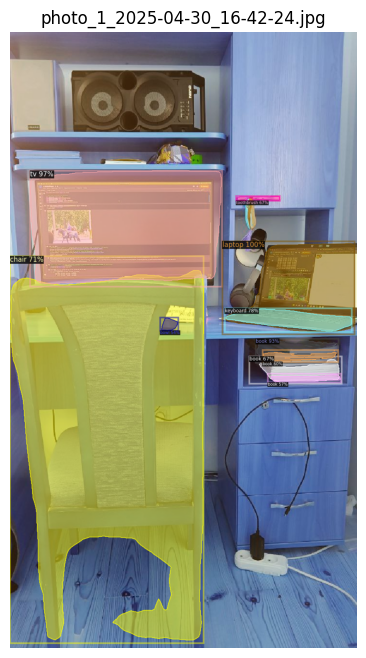

Обробка зображення: photo_2_2025-04-30_16-42-24.jpg


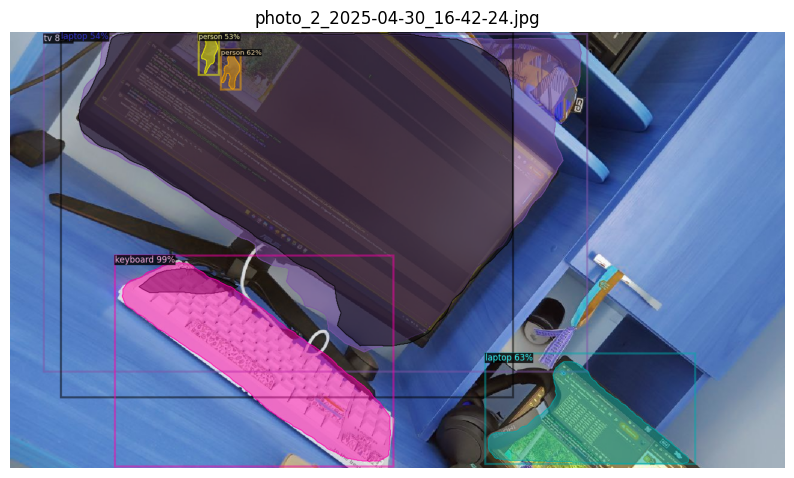

Обробка зображення: photo_3_2025-04-30_16-42-24.jpg


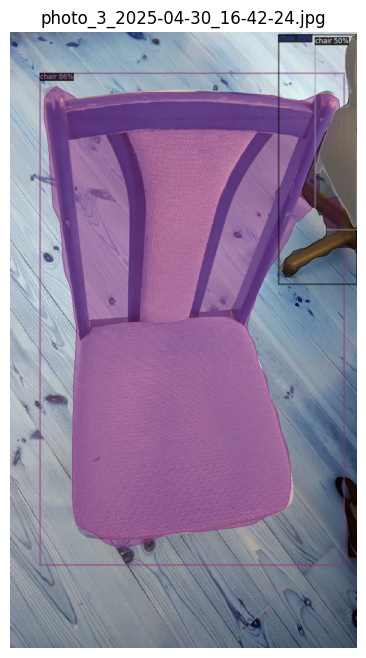

Обробка зображення: photo_4_2025-04-30_16-42-24.jpg


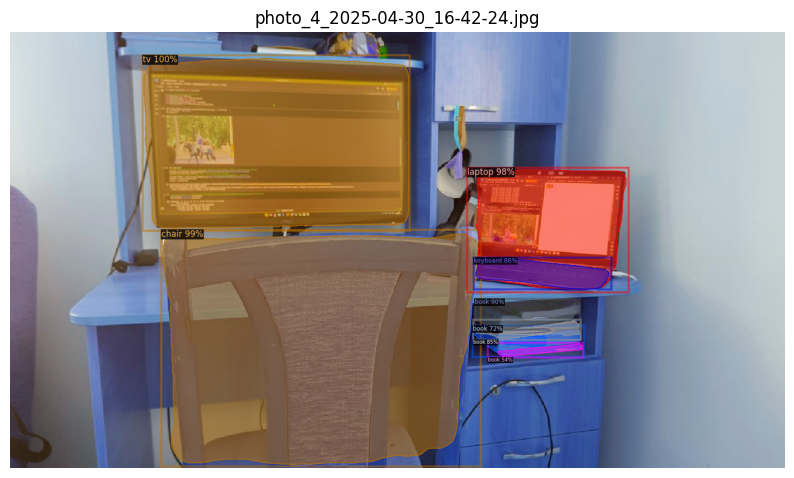

Обробка зображення: photo_5_2025-04-30_16-42-24.jpg


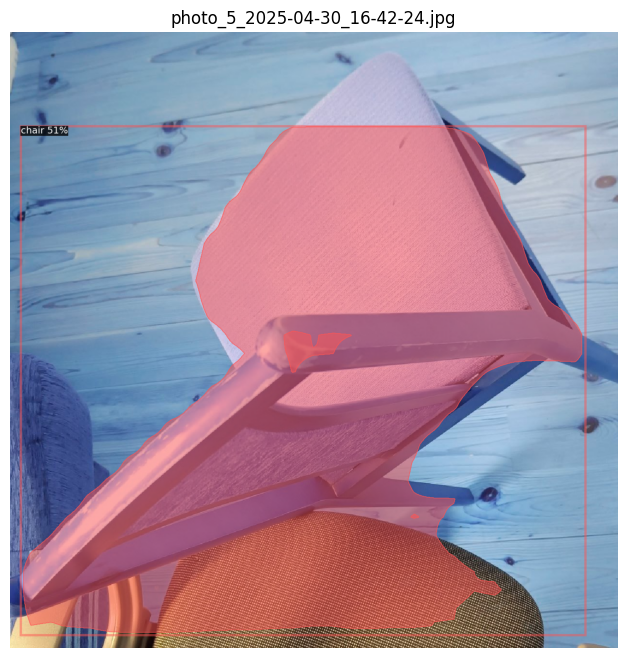

Обробка зображення: photo_6_2025-04-30_16-42-24.jpg


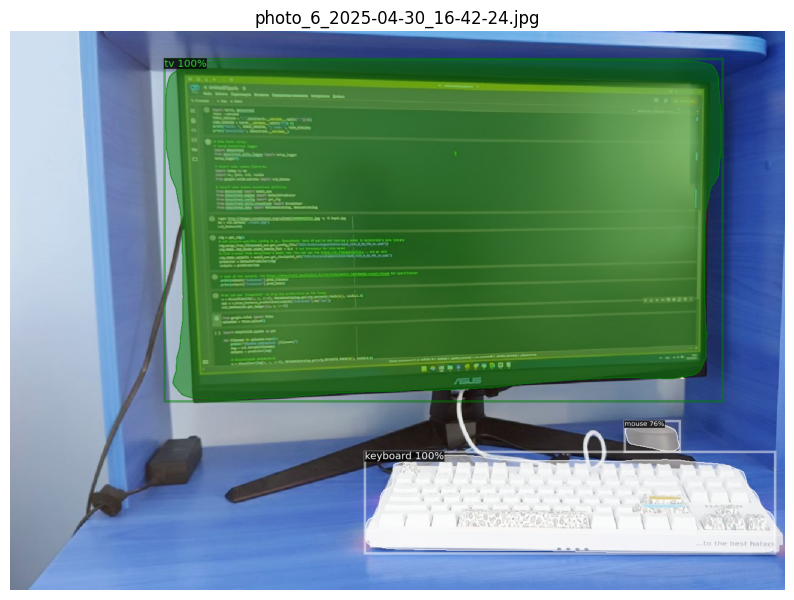

Обробка зображення: photo_7_2025-04-30_16-42-24.jpg


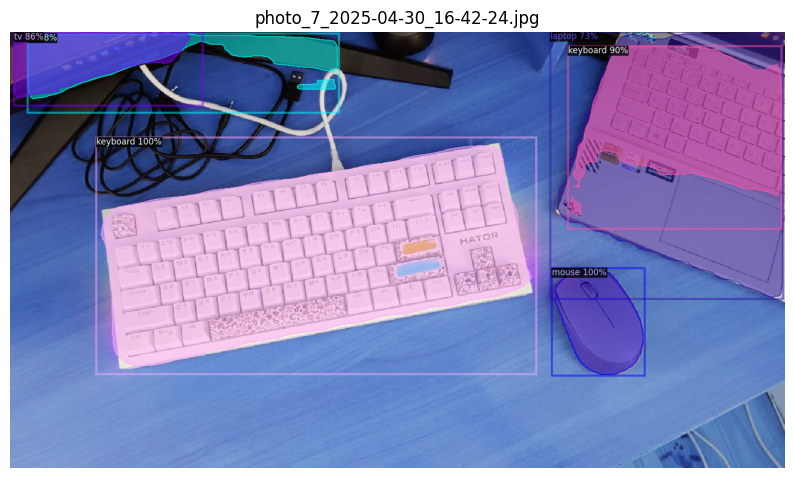

Обробка зображення: photo_8_2025-04-30_16-42-24.jpg


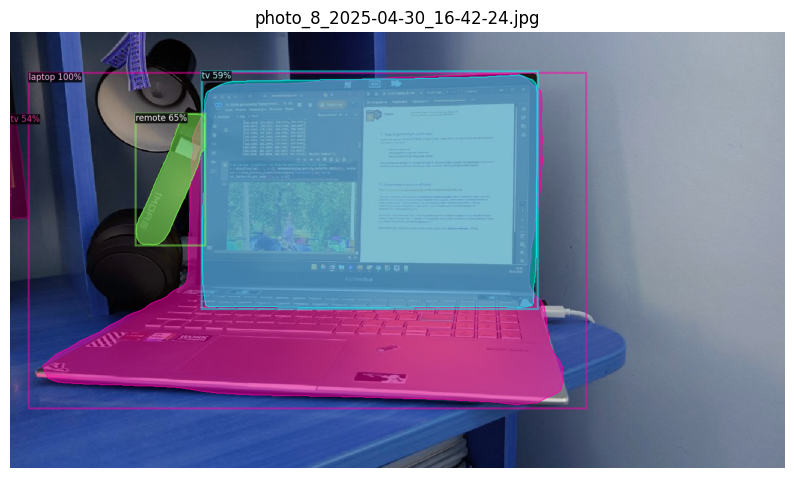

Обробка зображення: photo_9_2025-04-30_16-42-24.jpg


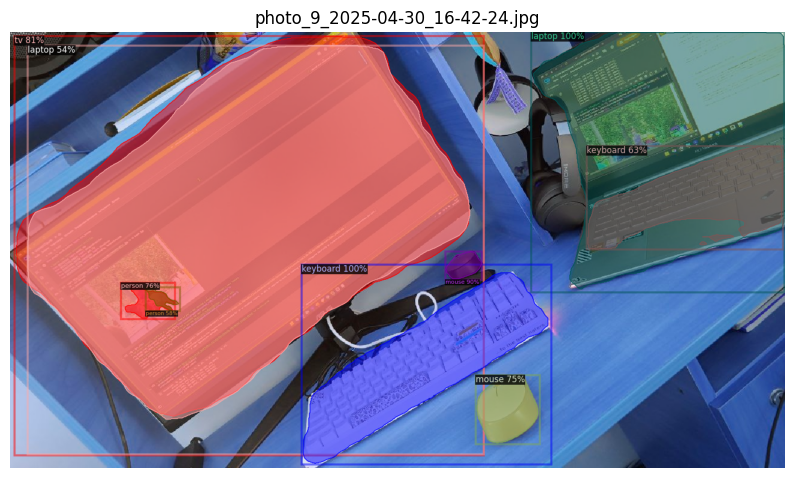

Обробка зображення: photo_10_2025-04-30_16-42-24.jpg


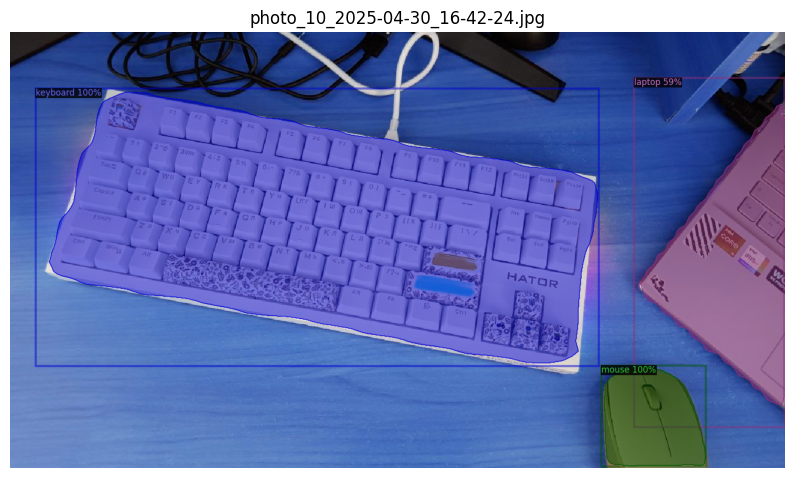

Обробка зображення: photo_11_2025-04-30_16-42-24.jpg


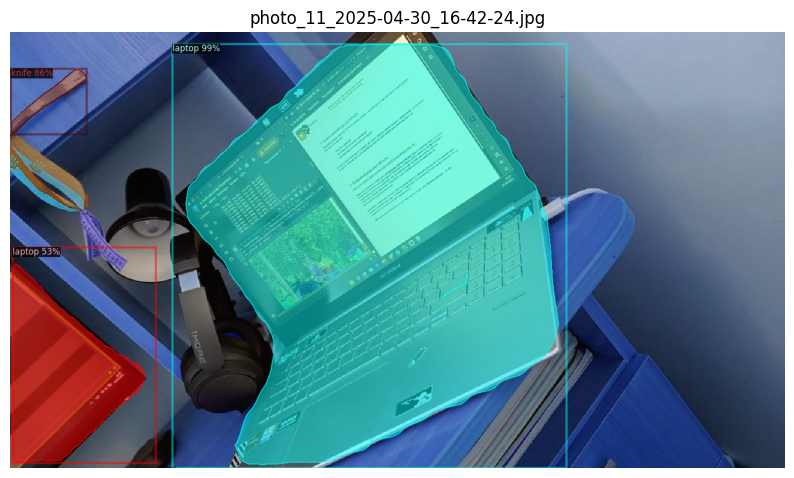

Обробка зображення: photo_12_2025-04-30_16-42-24.jpg


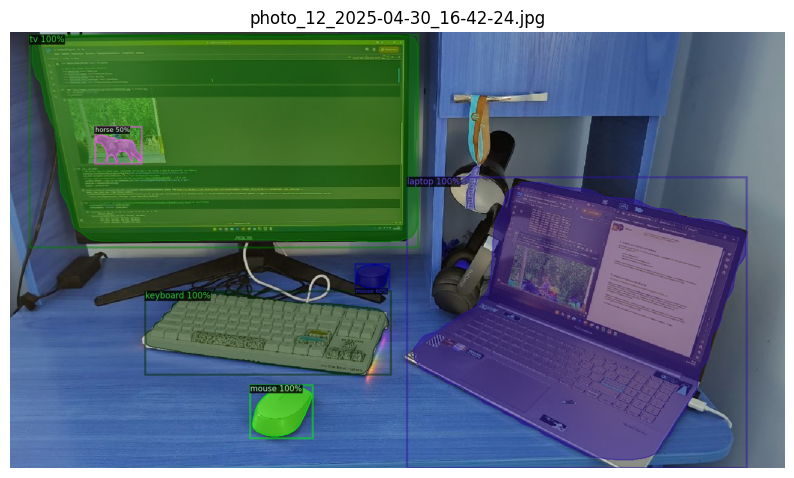

Обробка зображення: photo_13_2025-04-30_16-42-24.jpg


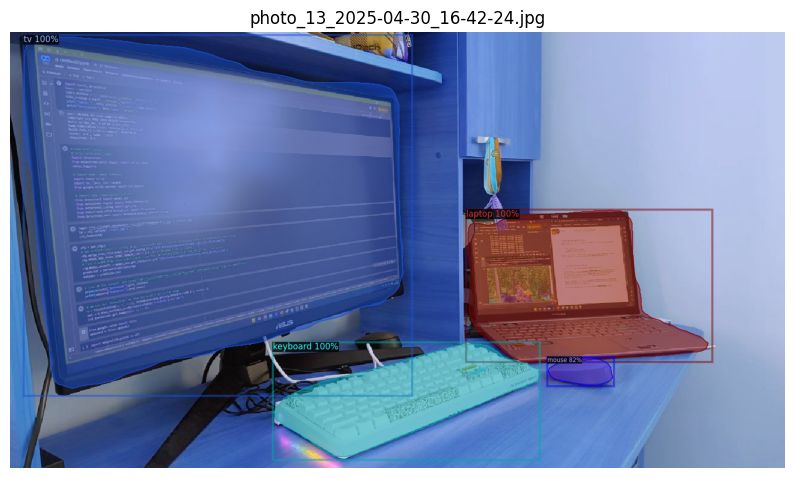

Обробка зображення: photo_14_2025-04-30_16-42-24.jpg


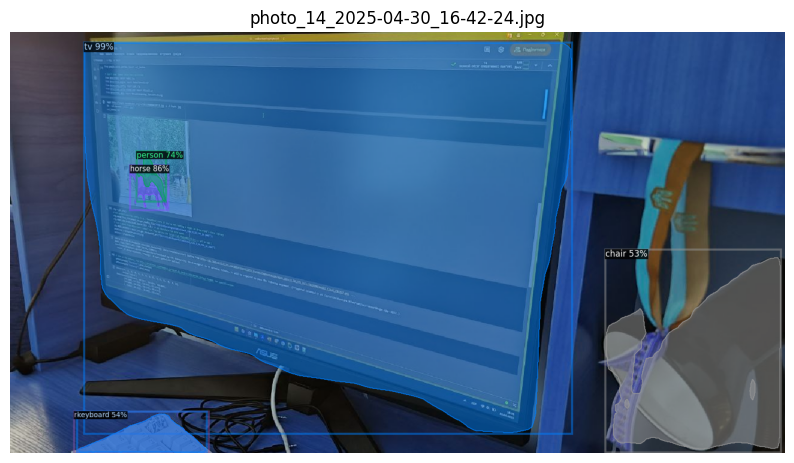

In [ ]:
import matplotlib.pyplot as plt

for filename in uploaded.keys():
    print(f"Обробка зображення: {filename}")
    img = cv2.imread(filename)
    outputs = predictor(img)

    v = Visualizer(img[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    result_img = out.get_image()[:, :, ::-1]

    plt.figure(figsize=(10, 8))
    plt.title(filename)
    plt.axis('off')
    plt.imshow(result_img)
    plt.show()

## Коментар до результатів

У ході тестування моделі Detectron2 були виявлені як успішні визначення об’єктів, так і певні помилки. Наприклад, навушники були розпізнані як "пульт", лампа — як "стілець", ручка на дверях — як "ніж", а монітор, знятий під кутом, модель визначила як "ноутбук". У всіх випадках звичайний монітор визначався як "телевізор", що, в принципі, є допустимим — враховуючи зовнішню схожість і обмежену деталізацію класифікацій у COCO-датасеті.

Такі помилки свідчать про залежність якості розпізнавання від перспективи, масштабу об'єкта, а також його контексту на зображенні. Коли фон складний або об’єкт займає незвичну позицію, модель може робити помилки через обмежену кількість схожих прикладів у тренувальному наборі. Проте, загалом, результати є цілком прийнятними для моделі, що не була донавчена на мої конкретні об’єкти.
